In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
import seaborn as sns
pd.set_option('display.max_rows', None)

from numpy import asarray
from numpy import mean
from numpy import std
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from matplotlib import pyplot

import xgboost
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight


In [2]:
train = pd.read_parquet('data/train.parquet')
test = pd.read_parquet('data/test.parquet')
#val = pd.read_parquet('data/val.parquet')

In [3]:
x_cols = ['Cos_DayOfYear',
 'AvgPacketLen_Mean',
 'Min_PacketSpeed',
 'Min_DataSpeed',
 'Attack ID',
 'PacketSpeed_Per_Second',
 'DayOfYear',
 'PCA_3',
 'Max_DetectCount',
 'AvgPacketLen_Per_TotalSeconds',
 'AvgPacketLen_Std',
 'Mean_PacketSpeed',
 'dist_centroid_silhouette_72',
 'dist_centroid_silhouette_54',
 'Data speed',
 'Source IP count',
 'Avg source IP count',
 'Max_DataSpeed',
 'umap_2',
 'Is_SSH',
 'total_seconds',
 'Max_PacketSpeed',
 'PCA_2',
 'PCA_4',
 'Std_DataSpeed',
 'VictimIP_Count',
 'dist_centroid_silhouette_61',
 'Victim IP',
 'Start Hour',
 'Mean_DetectCount',
 'Mean_DataSpeed',
 'Std_DetectCount',
 'Sin_DayOfYear']

In [4]:
x_cols = ['Attack ID', 'Avg source IP count', 'Detect count', 'Victim IP', 'Port number', 'Packet speed', 
          'Data speed', 'Avg packet len', 'Source IP count', 
          'Packet speed_normalized', 'Data speed_normalized', 'Avg packet len_normalized', 
          'total_seconds', 'weekday_number', 'time_of_day', 'IsWeekend', 'Start Hour', 'Sin_Hour', 
          'Cos_Hour', 'DayOfYear', 'Sin_DayOfYear', 'Cos_DayOfYear', 'Mean_DataSpeed', 'Std_DataSpeed', 
          'Min_DataSpeed', 'Max_DataSpeed', 'Mean_PacketSpeed', 'Min_PacketSpeed', 
          'Max_PacketSpeed', 'Mean_DetectCount', 'Std_DetectCount', 'Min_DetectCount', 'Max_DetectCount', 
          'VictimIP_Count', 'PortNumber_Count', 'AvgPacketLen_Mean', 'AvgPacketLen_Std', 
          'DataSpeed_PacketSpeed', 'PortFrequency', 'Std_DataSpeed_Replaced', 'Std_DetectCount_Replaced', 
          'AvgPacketLen_Std_Replaced', 'packet_Total', 'PacketSpeed_Per_Second',
          'DataSpeed_Per_TotalSeconds', 'AvgPacketLen_Per_TotalSeconds', 'Is_HTTP', 'Is_HTTPS', 
          'Is_FTP_Control', 'Is_FTP_Data', 'Is_SSH', 'Is_Telnet', 'Is_SMTP', 'Is_DNS', 'Is_POP3',
          'Is_IMAP', 'Is_DHCP', 'Is_SNMP', 'Is_LDAP', 'Is_LDAPS', 'Is_SMB_CIFS', 'Is_RDP', 'Is_SIP', 
          'Is_TFTP', 'Is_MySQL', 'Is_PostgreSQL', 'Is_Oracle', 'Is_HTTP_Alt_8080', 'Is_HTTP_Alt_8081',
          'Is_HTTP_Alt_80', 'Is_HTTPS_Alt_8443', 'Is_Syslog', 'Is_VNC', 'Is_IRC', 'Is_NTP', 'Is_Kerberos', 
          'Is_LDAP_Alt', 'Is_LDAPS_Alt', 'Is_RADIUS', 'Is_PPTP', 'Is_RTSP', 'Is_X11', 'Is_SNMP_Trap', 
          'Is_BGP', 'Is_IMAPS_Alt', 'Is_POP3S_Alt', 'Is_Telnet_SSL', 'Is_NNTP', 'Is_NNTPS', 'Is_LDAP_TLS', 
          'Is_AFS', 'Is_NFS', 'Is_SOCKS', 'Is_RSYNC', 'Is_CUPS', 'Is_TFTP_Alt', 'Is_Modbus', 'Is_CoAP', 
          'Is_MQTT', 'Is_AMQP', 'Is_Redis', 'Is_Memcached', 'Is_Elasticsearch', 'Is_Zookeeper', 
          'Is_Cassandra', 'Is_Docker', 'Is_Kubernetes', 'Is_SMB_Direct', 'Is_iSCSI', 'Is_AFP', 
          'Is_DHCPv6', 'Is_RIPng', 'Is_OSPF', 'Is_PPPoE', 'Is_L2TP', 'Is_GRE', 'Is_ESP', 'Is_AH',
          'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'cluster', 'cluster112', 'dist_centroid_0',
          'dist_centroid_1', 'dist_centroid_2', 'dist_centroid_3', 'dist_centroid_4',
          'dist_centroid_5', 'dist_centroid_6', 'dist_centroid_7', 'dist_centroid_8',
          'dist_centroid_9', 'dist_centroid_10', 'dist_centroid_11', 'dist_centroid_12',
          'dist_centroid_13', 'dist_centroid_14', 'dist_centroid_15', 'dist_centroid_16','dist_centroid_17',
          'dist_centroid_silhouette_1', 'dist_centroid_silhouette_2', 'dist_centroid_silhouette_3',
          'dist_centroid_silhouette_4', 'dist_centroid_silhouette_5', 'dist_centroid_silhouette_6',
          'dist_centroid_silhouette_7','dist_centroid_silhouette_8','dist_centroid_silhouette_9',
          'dist_centroid_silhouette_10','dist_centroid_silhouette_11','dist_centroid_silhouette_12',
          'dist_centroid_silhouette_13','dist_centroid_silhouette_14','dist_centroid_silhouette_15',
          'dist_centroid_silhouette_16','dist_centroid_silhouette_17','dist_centroid_silhouette_18',
          'dist_centroid_silhouette_19','dist_centroid_silhouette_20','dist_centroid_silhouette_21',
          'dist_centroid_silhouette_22','dist_centroid_silhouette_23','dist_centroid_silhouette_24',
          'dist_centroid_silhouette_25','dist_centroid_silhouette_26','dist_centroid_silhouette_27',
          'dist_centroid_silhouette_28','dist_centroid_silhouette_29','dist_centroid_silhouette_30',
          'dist_centroid_silhouette_31','dist_centroid_silhouette_32','dist_centroid_silhouette_33',
          'dist_centroid_silhouette_34','dist_centroid_silhouette_35','dist_centroid_silhouette_36',
          'dist_centroid_silhouette_37','dist_centroid_silhouette_38','dist_centroid_silhouette_39',
          'dist_centroid_silhouette_40','dist_centroid_silhouette_41','dist_centroid_silhouette_42',
          'dist_centroid_silhouette_43','dist_centroid_silhouette_44','dist_centroid_silhouette_45',
          'dist_centroid_silhouette_46','dist_centroid_silhouette_47','dist_centroid_silhouette_48',
          'dist_centroid_silhouette_49','dist_centroid_silhouette_50','dist_centroid_silhouette_51',
          'dist_centroid_silhouette_52','dist_centroid_silhouette_53','dist_centroid_silhouette_54',
 'dist_centroid_silhouette_55',
 'dist_centroid_silhouette_56',
 'dist_centroid_silhouette_57',
 'dist_centroid_silhouette_58',
 'dist_centroid_silhouette_59',
 'dist_centroid_silhouette_60',
 'dist_centroid_silhouette_61',
 'dist_centroid_silhouette_62',
 'dist_centroid_silhouette_63',
 'dist_centroid_silhouette_64',
 'dist_centroid_silhouette_65',
 'dist_centroid_silhouette_66',
 'dist_centroid_silhouette_67',
 'dist_centroid_silhouette_68',
 'dist_centroid_silhouette_69',
 'dist_centroid_silhouette_70',
 'dist_centroid_silhouette_71',
 'dist_centroid_silhouette_72',
 'dist_centroid_silhouette_73',
 'dist_centroid_silhouette_74',
 'dist_centroid_silhouette_75',
 'dist_centroid_silhouette_76',
 'dist_centroid_silhouette_77',
 'dist_centroid_silhouette_78',
 'dist_centroid_silhouette_79',
 'dist_centroid_silhouette_80',
 'dist_centroid_silhouette_81',
 'dist_centroid_silhouette_82',
 'dist_centroid_silhouette_83',
 'dist_centroid_silhouette_84',
 'dist_centroid_silhouette_85',
 'dist_centroid_silhouette_86',
 'dist_centroid_silhouette_87',
 'dist_centroid_silhouette_88',
 'dist_centroid_silhouette_89',
 'dist_centroid_silhouette_90',
 'dist_centroid_silhouette_91',
 'dist_centroid_silhouette_92',
 'dist_centroid_silhouette_93',
 'dist_centroid_silhouette_94',
 'dist_centroid_silhouette_95',
 'dist_centroid_silhouette_96',
 'dist_centroid_silhouette_97',
 'dist_centroid_silhouette_98',
 'dist_centroid_silhouette_99',
 'dist_centroid_silhouette_100',
 'dist_centroid_silhouette_101',
 'dist_centroid_silhouette_102',
 'dist_centroid_silhouette_103',
 'dist_centroid_silhouette_104',
 'dist_centroid_silhouette_105',
 'dist_centroid_silhouette_106',
 'dist_centroid_silhouette_107',
 'dist_centroid_silhouette_108',
 'dist_centroid_silhouette_109',
 'dist_centroid_silhouette_110',
 'dist_centroid_silhouette_111', 
 'tsne_1','tsne_0', 'umap_1', 'umap_2']

In [5]:
def evaluate(model):
    model.fit(train[x_cols], train['Type'])

    # Predict the labels for the test data
    test['pred'] = model.predict(test[x_cols])

    # Generate the classification report
    report = classification_report(test['pred'], test['Type'])

    # Print the classification report
    print(report)
    # 1. Generate the confusion matrix
    cm = confusion_matrix(test['Type'], test['pred'])

    # 2. Visualize the confusion matrix (optional, but highly recommended)
    class_labels = np.unique(test['Type']) # Get unique class labels

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    # 3. Print the confusion matrix (textual representation)
    print(cm)

    # 1. Generate the classification report as a dictionary
    report = classification_report(test['Type'], test['pred'], output_dict=True)

    # 2. Extract the data for plotting
    classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
    precision = [report[cls]['precision'] for cls in classes]
    recall = [report[cls]['recall'] for cls in classes]
    f1_score = [report[cls]['f1-score'] for cls in classes]

    # 3. Set up the plot
    x = np.arange(len(classes))
    width = 0.2

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width, precision, width, label='Recall')
    rects2 = ax.bar(x, recall, width, label='Precision')
    rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Score')
    ax.set_xlabel('Classes')
    ax.set_title('Classification Report per Class')
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.legend()

    ax.bar_label(rects1, fmt='%.2f', padding=3)
    ax.bar_label(rects2, fmt='%.2f', padding=3)
    ax.bar_label(rects3, fmt='%.2f', padding=3)

    fig.tight_layout()
    plt.show()

In [6]:
def evaluate_xgb(model):

    sample_weights = compute_sample_weight(
        class_weight='balanced',
        y=train['Type']
    )
    model.fit(train[x_cols], train['Type'], sample_weight=sample_weights)

    # Predict the labels for the test data
    test['pred'] = model.predict(test[x_cols])

    # Generate the classification report
    report = classification_report(test['pred'], test['Type'])

    # Print the classification report
    print(report)
    # 1. Generate the confusion matrix
    cm = confusion_matrix(test['Type'], test['pred'])

    # 2. Visualize the confusion matrix (optional, but highly recommended)
    class_labels = np.unique(test['Type']) # Get unique class labels

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    # 3. Print the confusion matrix (textual representation)
    print(cm)

    # 1. Generate the classification report as a dictionary
    report = classification_report(test['Type'], test['pred'], output_dict=True)

    # 2. Extract the data for plotting
    classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
    precision = [report[cls]['precision'] for cls in classes]
    recall = [report[cls]['recall'] for cls in classes]
    f1_score = [report[cls]['f1-score'] for cls in classes]

    # 3. Set up the plot
    x = np.arange(len(classes))
    width = 0.2

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width, precision, width, label='Recall')
    rects2 = ax.bar(x, recall, width, label='Precision')
    rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Score')
    ax.set_xlabel('Classes')
    ax.set_title('Classification Report per Class')
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.legend()

    ax.bar_label(rects1, fmt='%.2f', padding=3)
    ax.bar_label(rects2, fmt='%.2f', padding=3)
    ax.bar_label(rects3, fmt='%.2f', padding=3)

    fig.tight_layout()
    plt.show()

# RFC


In [5]:
x_cols = ['Min_PacketSpeed',
 'Std_DataSpeed',
 'Std_DetectCount',
 'Mean_DetectCount',
 'Avg source IP count',
 'Max_DetectCount',
 'Attack ID',
 'Max_PacketSpeed',
 'total_seconds',
 'AvgPacketLen_Std',
 'Mean_DataSpeed',
 'Mean_PacketSpeed',
 'Source IP count',
 'Cos_DayOfYear',
 'Sin_DayOfYear',
 'DayOfYear',
 'AvgPacketLen_Mean',
 'Min_DataSpeed',
 'PCA_4',
 'Start Hour']

              precision    recall  f1-score   support

           0       0.74      0.59      0.66    382025
           1       0.85      0.90      0.87    860804
           2       0.19      0.96      0.31      4437

    accuracy                           0.81   1247266
   macro avg       0.59      0.82      0.62   1247266
weighted avg       0.81      0.81      0.81   1247266



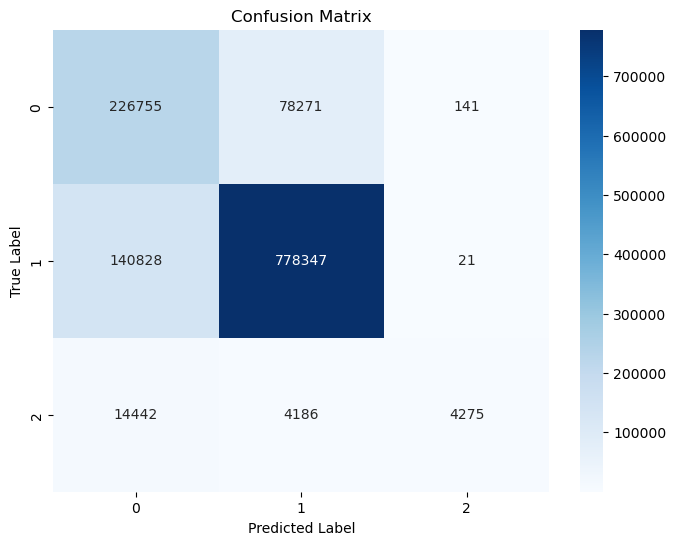

[[226755  78271    141]
 [140828 778347     21]
 [ 14442   4186   4275]]


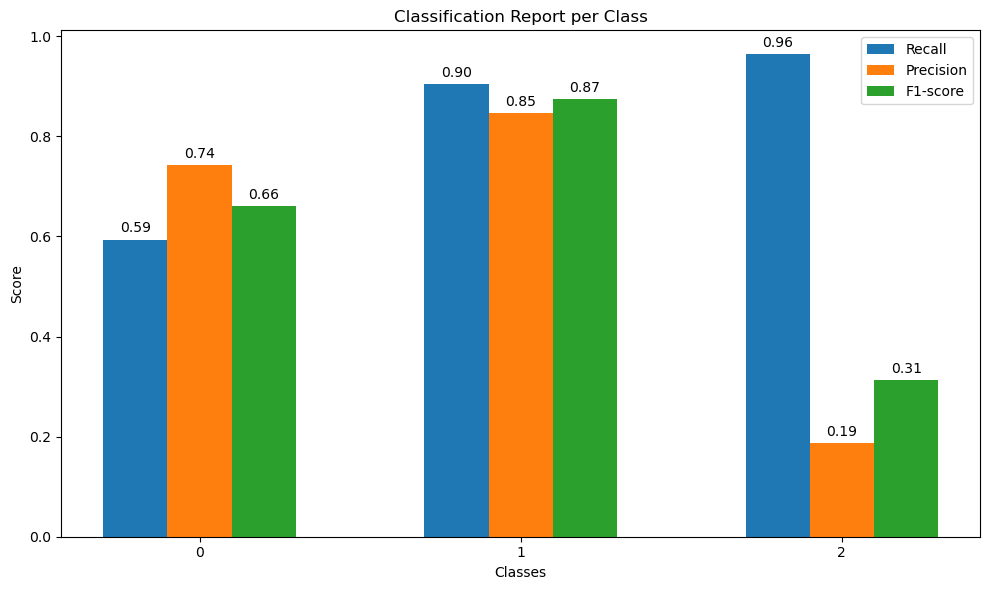

In [10]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest classifier
#{'n_estimators': 287, 'max_depth': 22, 'min_samples_split': 4, 'min_samples_leaf': 5}
#{'n_estimators': 390, 'max_depth': 24, 'min_samples_split': 8, 'min_samples_leaf': 1}
rfc = RandomForestClassifier(n_estimators=390, max_depth=24, min_samples_split=8, min_samples_leaf=1, random_state=42, class_weight='balanced')
#RandomForestClassifier(n_estimators=437, random_state=42, max_depth=37, min_samples_split=10, min_samples_leaf=5, verbose=1)
evaluate(rfc)

              precision    recall  f1-score   support

           0       0.19      0.74      0.30     76221
           1       0.98      0.77      0.86   1166420
           2       0.19      0.96      0.32      4625

    accuracy                           0.77   1247266
   macro avg       0.45      0.83      0.49   1247266
weighted avg       0.93      0.77      0.83   1247266



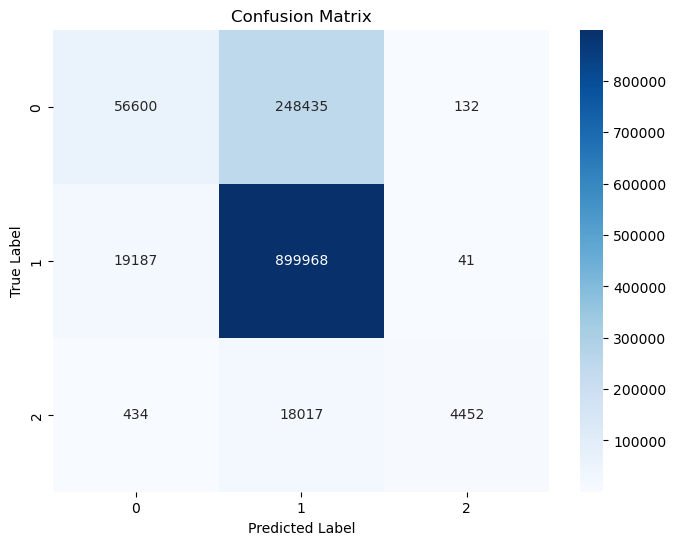

[[ 56600 248435    132]
 [ 19187 899968     41]
 [   434  18017   4452]]


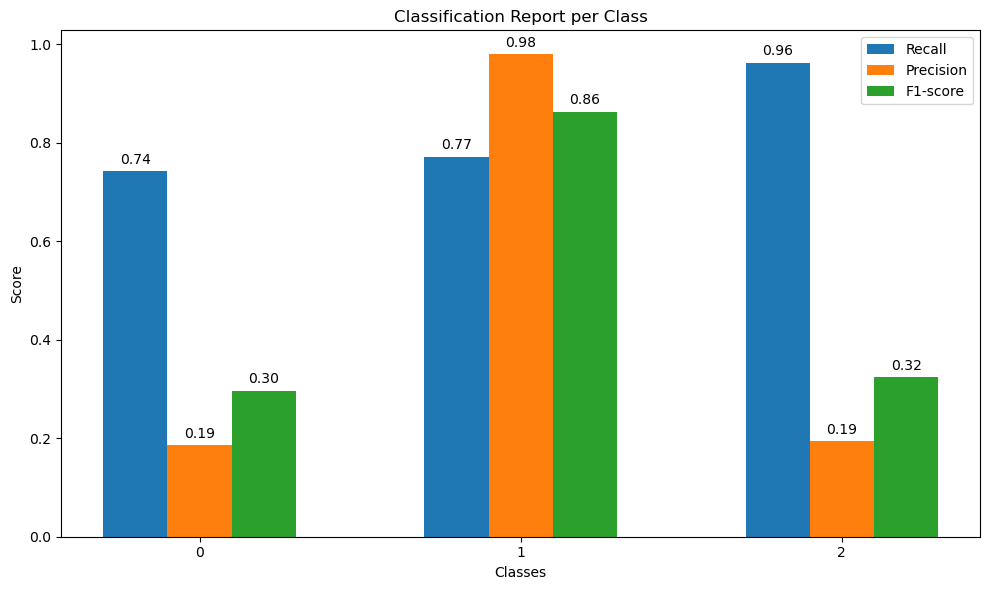

In [6]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest classifier
#{'n_estimators': 236, 'max_depth': 23, 'min_samples_split': 5, 'min_samples_leaf': 1}
rfc = RandomForestClassifier(n_estimators=236, max_depth=23, min_samples_split=5, min_samples_leaf=1, random_state=42, class_weight='balanced')
#RandomForestClassifier(n_estimators=437, random_state=42, max_depth=37, min_samples_split=10, min_samples_leaf=5, verbose=1)
evaluate(rfc)

              precision    recall  f1-score   support

           0       0.56      0.65      0.60    265519
           1       0.91      0.86      0.88    976777
           2       0.21      0.96      0.34      4970

    accuracy                           0.81   1247266
   macro avg       0.56      0.82      0.61   1247266
weighted avg       0.84      0.81      0.82   1247266



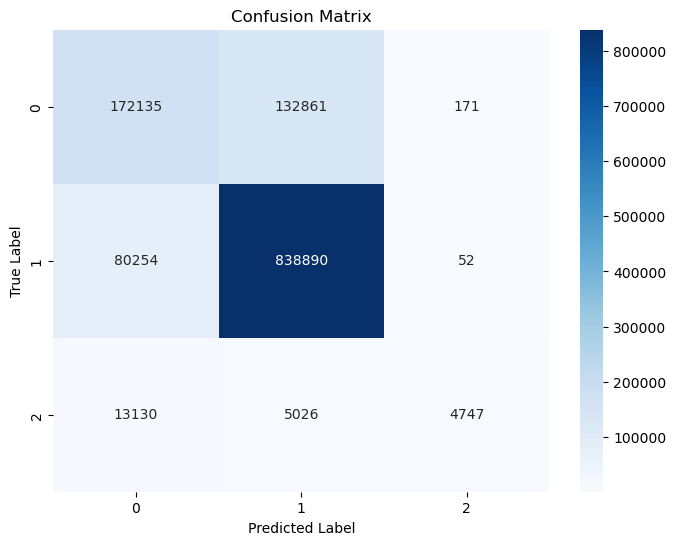

[[172135 132861    171]
 [ 80254 838890     52]
 [ 13130   5026   4747]]


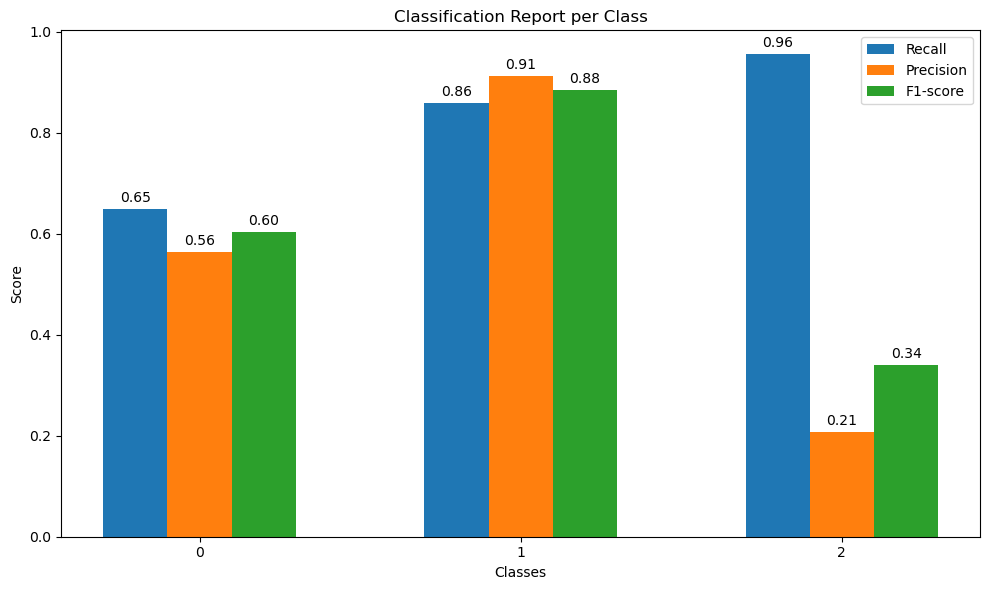

In [7]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest classifier
#{'n_estimators': 236, 'max_depth': 23, 'min_samples_split': 5, 'min_samples_leaf': 1}
rfc = RandomForestClassifier(n_estimators=236, max_depth=23, min_samples_split=5, min_samples_leaf=1, random_state=42)
#RandomForestClassifier(n_estimators=437, random_state=42, max_depth=37, min_samples_split=10, min_samples_leaf=5, verbose=1)
evaluate(rfc)

In [7]:
importances = rfc.feature_importances_
feature_importances = pd.DataFrame({'Feature': x_cols, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False).reset_index(drop=True)

top_features = feature_importances.head(20)
top_feature_names = top_features['Feature'].tolist()
top_feature_names

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

Feature Importances for Random Forest Classifier:
                          Feature  Importance
0             Avg source IP count    0.090946
1                Mean_DetectCount    0.079345
2                 Min_PacketSpeed    0.079342
3                   Std_DataSpeed    0.073811
4                       Attack ID    0.062949
5                  Mean_DataSpeed    0.061858
6                   total_seconds    0.059458
7                Mean_PacketSpeed    0.058961
8                 Max_PacketSpeed    0.057071
9                AvgPacketLen_Std    0.048734
10              AvgPacketLen_Mean    0.044684
11                  Min_DataSpeed    0.043605
12                  Sin_DayOfYear    0.039994
13                  Max_DataSpeed    0.038582
14                      DayOfYear    0.036838
15  AvgPacketLen_Per_TotalSeconds    0.033954
16                  Cos_DayOfYear    0.029927
17                 VictimIP_Count    0.027493
18                      Victim IP    0.017712
19                 weekday_num

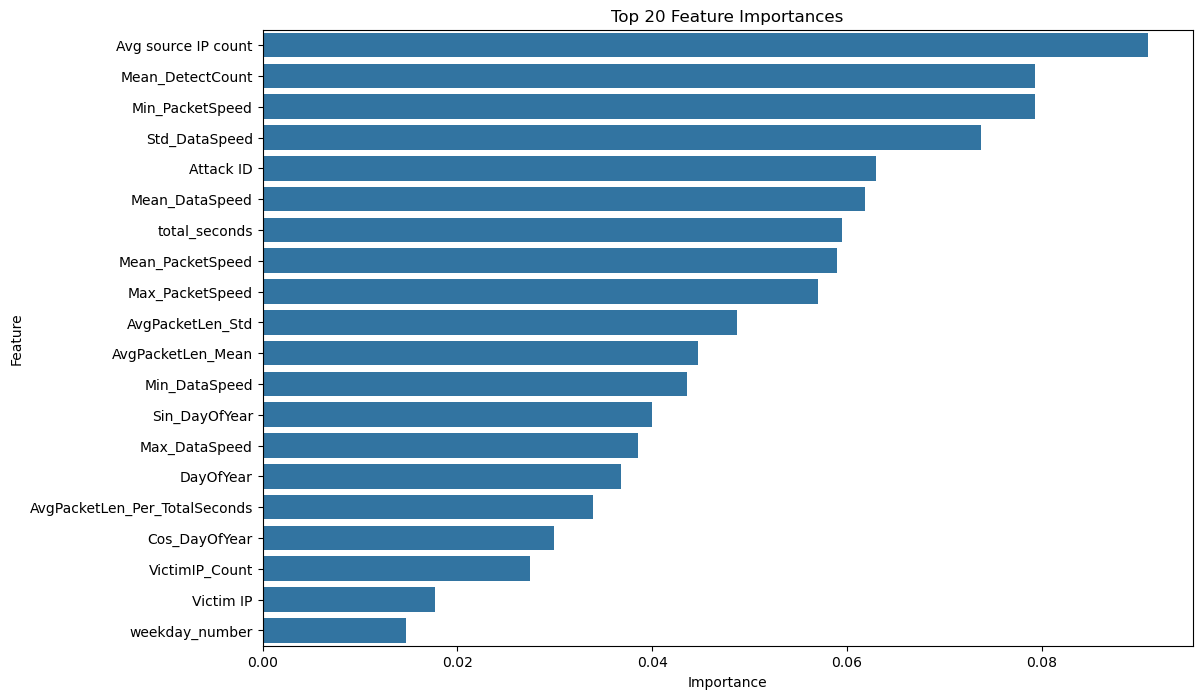

In [6]:
# Function to display feature importances
def display_feature_importances(model, features):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        feature_importances = pd.DataFrame({'Feature': features, 'Importance': importances})
        feature_importances = feature_importances.sort_values(by='Importance', ascending=False).reset_index(drop=True)
        
        print(feature_importances)
        
        plt.figure(figsize=(12, 8))
        sns.barplot(x='Importance', y='Feature', data=feature_importances.head(20)) # Plot top 20
        plt.title('Top 20 Feature Importances')
        plt.show()
    else:
        print("Model does not provide feature importances.")

# Display for RFC (Random Forest Classifier)
print("Feature Importances for Random Forest Classifier:")
display_feature_importances(rfc, x_cols)

In [24]:
test[test['cluster'].isin([1,2,3,4,5,6,7,8,10,11,12,13,14,15,16,18,19])]['Type'].value_counts()

Type
0    26552
1     1630
2      272
Name: count, dtype: int64

In [20]:
test[test['cluster112'].isin([1,2,3,4,5,6,7,11,12,13,16,17,20,21,22,25,26,27,28,29,30,40,41,42,43,44,49,50,51,52,55,56,57,59,60,65,66,67,68,69,70,73,74,75,76,77,78,79,80,81,82,83,84,88,89,90,91,92,93,94,95,96,97,99,100,101,102,103,104,105,106,107,108,109,110])]['Type'].value_counts()

Type
0    3945
1       4
2       3
Name: count, dtype: int64

In [21]:
# After SMOTE *2
"""Accuracy: 0.8212698814847835
Precision: 0.6796352669253373
Recall: 0.5641607988228415
F1-Score: 0.5968541729821948"""

# After SMOTE *1.5
"""Accuracy: 0.8317616290350254
Precision: 0.8383765643300584
Recall: 0.5832465366868779
F1-Score: 0.6230823834637998"""

# After SMOTE *1.2
"""Accuracy: 0.8205282594089793
Precision: 0.8171876601009965
Recall: 0.5604558516901181
F1-Score: 0.6038335264459057"""

# After SMOTE *1.7
"""Accuracy: 0.7814820575562871
Precision: 0.5873932085311964
Recall: 0.6415121998728757
F1-Score: 0.599508817810126"""



# ROUND 2
"""Accuracy: 0.8412231232150961
Precision: 0.8303405069778947
Recall: 0.5715682661763412
F1-Score: 0.618068275503768"""

'Accuracy: 0.8412231232150961\nPrecision: 0.8303405069778947\nRecall: 0.5715682661763412\nF1-Score: 0.618068275503768'

# GBM


      Iter       Train Loss   Remaining Time 
         1           0.5111           25.24m
         2           0.4758           24.87m
         3           0.4393           24.45m
         4           0.4131           24.06m
         5           0.3963           23.73m
         6           0.3771           23.54m
         7           0.3626           23.41m
         8           0.3478           23.01m
         9           0.3366           22.80m
        10           0.3247           22.66m
        20           0.2546           20.37m
        30           0.2197           17.84m
        40           0.1946           15.31m
        50           0.1766           12.77m
        60           0.1616           10.24m
        70           0.1491            7.68m
        80           0.1384            5.13m
        90           0.1301            2.56m
       100           0.1216            0.00s
              precision    recall  f1-score   support

           0       0.63      0.59      0.61 

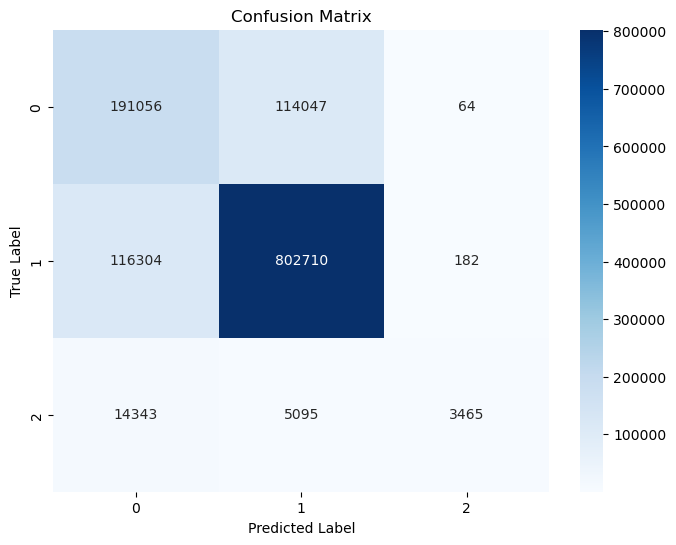

[[191056 114047     64]
 [116304 802710    182]
 [ 14343   5095   3465]]


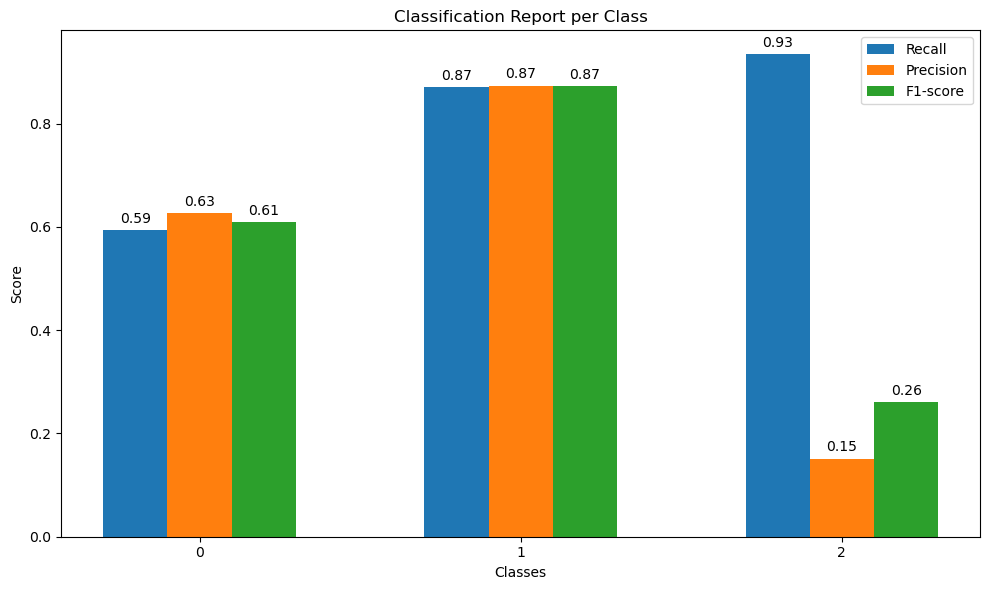

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# Import necessary libraries
from sklearn.ensemble import GradientBoostingClassifier
# Initialize the Gradient Boosting Classifier
gbc = GradientBoostingClassifier(random_state=42, verbose=1)

evaluate(gbc)

In [23]:
# After SMOTE *1.5
"""Accuracy: 0.7537750568042423
Precision: 0.5499038794403751
Recall: 0.6752129126613243
F1-Score: 0.5814952853168204"""

'Accuracy: 0.7537750568042423\nPrecision: 0.5499038794403751\nRecall: 0.6752129126613243\nF1-Score: 0.5814952853168204'

# XGBoost


In [9]:
x_cols = ['dist_centroid_silhouette_72',
 'Avg source IP count',
 'PCA_4',
 'dist_centroid_silhouette_61',
 'PCA_3',
 'Std_DetectCount',
 'Is_SSH',
 'dist_centroid_silhouette_54',
 'Std_DataSpeed',
 'umap_2',
 'Min_PacketSpeed',
 'Data speed',
 'Mean_DetectCount',
 'Victim IP',
 'Min_DataSpeed',
 'AvgPacketLen_Mean',
 'Attack ID',
 'PacketSpeed_Per_Second',
 'PCA_2',
 'Mean_PacketSpeed']

              precision    recall  f1-score   support

           0       0.48      0.59      0.53    248621
           1       0.89      0.82      0.86    993272
           2       0.22      0.95      0.36      5373

    accuracy                           0.78   1247266
   macro avg       0.53      0.79      0.58   1247266
weighted avg       0.81      0.78      0.79   1247266



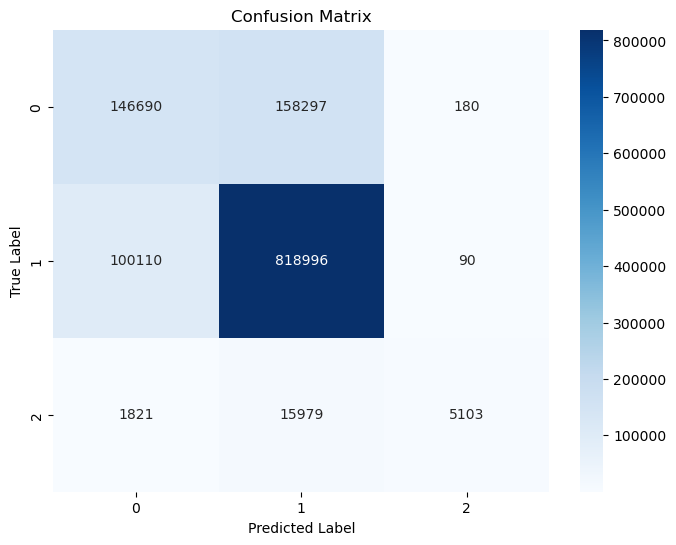

[[146690 158297    180]
 [100110 818996     90]
 [  1821  15979   5103]]


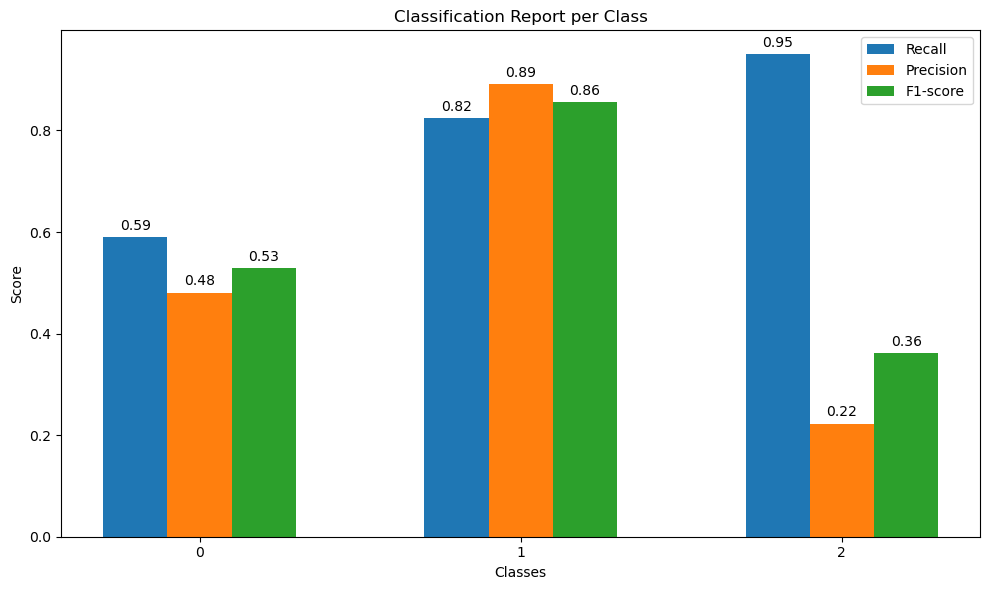

In [8]:
# xgboost for classification
from numpy import asarray
from numpy import mean
from numpy import std
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from matplotlib import pyplot
# Best hyperparameters: {'booster': 'dart', 'alpha': 0.6730647547618864, 'subsample': 0.42803065237564275, 'colsample_bytree': 0.8565965677640711, 
# 'max_depth': 5, 'eta': 0.179806132737519, 'gamma': 0.8114340643087419, 'grow_policy': 'lossguide', 'min_child_weight': 5}

#{'booster': 'gbtree', 'alpha': 0.6723042804277493, 'subsample': 0.701672592800581, 'colsample_bytree': 0.9038509812461704, 
# 'max_depth': 7, 'eta': 0.28125398065262164, 'gamma': 0.2907607913499124, 'grow_policy': 'depthwise', 'min_child_weight': 6}


xgbm = XGBClassifier(
    objective='multi:softmax',
        num_class=3,
        booster=('gbtree'),
        alpha=0.6723042804277493,
        subsample=0.701672592800581,
        colsample_bytree=0.9038509812461704,
        max_depth=7,
        eta=0.28125398065262164,
        gamma=0.2907607913499124,
        grow_policy='depthwise',
        min_child_weight=6,
        eval_metric='merror',  # Multi-class error for evaluation
        random_state=42
        )
evaluate_xgb(xgbm)

              precision    recall  f1-score   support

           0       0.41      0.62      0.49    201393
           1       0.92      0.81      0.86   1041165
           2       0.18      0.90      0.31      4708

    accuracy                           0.78   1247266
   macro avg       0.50      0.78      0.55   1247266
weighted avg       0.83      0.78      0.80   1247266



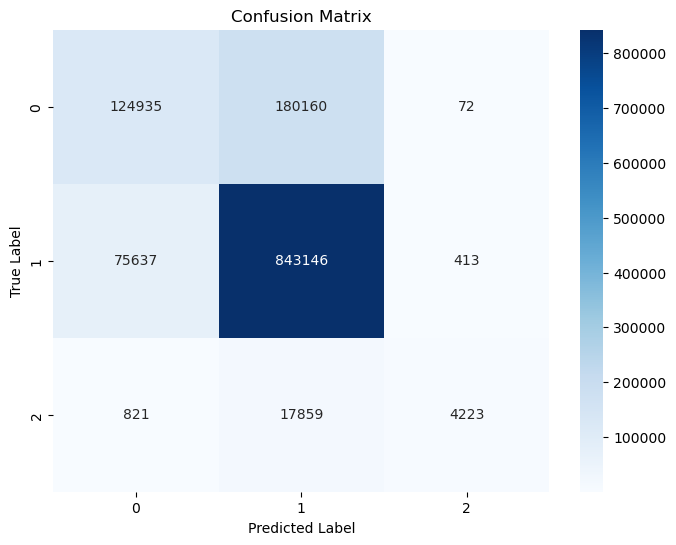

[[124935 180160     72]
 [ 75637 843146    413]
 [   821  17859   4223]]


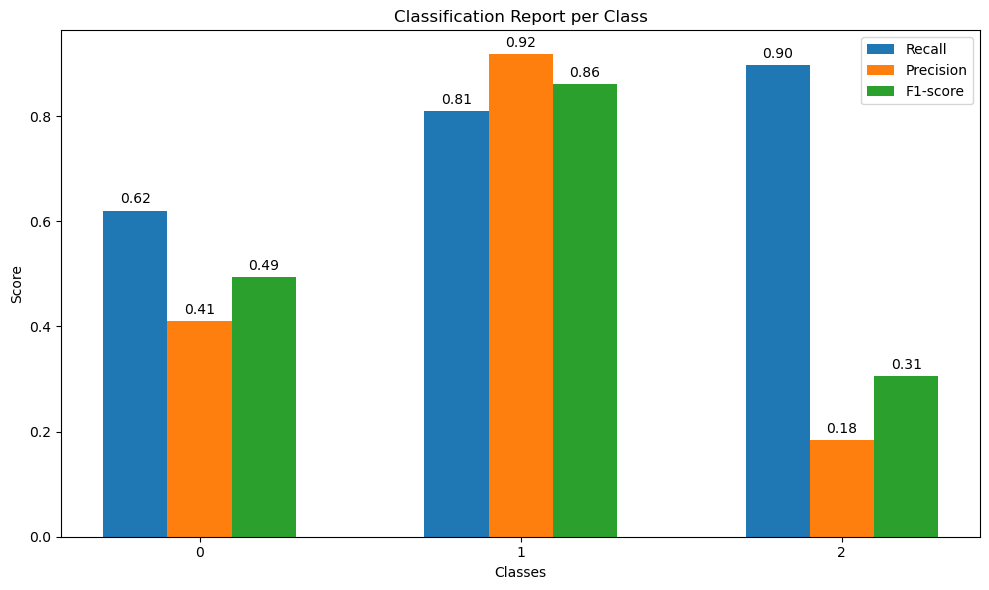

In [16]:
import xgboost
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# xgboost for classification
from numpy import asarray
from numpy import mean
from numpy import std
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from matplotlib import pyplot
# Best hyperparameters: {'booster': 'gbtree', 'alpha': 0.06702334489337117, 'subsample': 0.6999862064417001, 
# 'colsample_bytree': 0.6189751537820103, 'max_depth': 7, 'eta': 0.23408535710013775, 'gamma': 0.33012492037313645, 
# 'grow_policy': 'depthwise', 'min_child_weight': 7}

xgbm = XGBClassifier(
    objective='multi:softmax',
        num_class=3,
        booster=('gbtree'),
        alpha=0.06702334489337117,
        subsample=0.6999862064417001,
        colsample_bytree=0.6189751537820103,
        max_depth=7,
        eta=0.23408535710013775,
        gamma=0.33012492037313645,
        grow_policy='depthwise',
        min_child_weight=7,
        eval_metric='merror',  # Multi-class error for evaluation
        random_state=42,)
evaluate(xgbm)

In [10]:
importances = xgbm.feature_importances_
feature_importances = pd.DataFrame({'Feature': x_cols, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False).reset_index(drop=True)

top_features = feature_importances.head(20)
top_feature_names = top_features['Feature'].tolist()
top_feature_names

['dist_centroid_silhouette_72',
 'Avg source IP count',
 'PCA_4',
 'dist_centroid_silhouette_61',
 'PCA_3',
 'Std_DetectCount',
 'Is_SSH',
 'dist_centroid_silhouette_54',
 'Std_DataSpeed',
 'umap_2',
 'Min_PacketSpeed',
 'Data speed',
 'Mean_DetectCount',
 'Victim IP',
 'Min_DataSpeed',
 'AvgPacketLen_Mean',
 'Attack ID',
 'PacketSpeed_Per_Second',
 'PCA_2',
 'Mean_PacketSpeed']

In [11]:
#w smote
"""Accuracy: 0.761876776886406
Precision: 0.5359084300770789
Recall: 0.5724204312974694
F1-Score: 0.5501817911228063"""

#w smote
"""Accuracy: 0.7828698930300353
Precision: 0.7618986989713181
Recall: 0.5156758740397258
F1-Score: 0.5646436798588266"""

'Accuracy: 0.7828698930300353\nPrecision: 0.7618986989713181\nRecall: 0.5156758740397258\nF1-Score: 0.5646436798588266'

# LightGBM


In [7]:
x_cols = ['total_seconds',
 'AvgPacketLen_Mean',
 'Avg source IP count',
 'Max_DetectCount',
 'Std_DataSpeed',
 'AvgPacketLen_Std',
 'Min_PacketSpeed',
 'Sin_DayOfYear',
 'Cos_DayOfYear',
 'Mean_DataSpeed',
 'Max_DataSpeed',
 'Mean_PacketSpeed',
 'Attack ID',
 'Max_PacketSpeed',
 'Victim IP',
 'AvgPacketLen_Per_TotalSeconds',
 'Mean_DetectCount',
 'Start Hour',
 'Min_DataSpeed',
 'DayOfYear',
 'VictimIP_Count',
 'Std_DetectCount',
 'PCA_3',
 'PCA_4',
 'PacketSpeed_Per_Second',
 'Source IP count',
 'PCA_2',
 'umap_2',
 'Is_SSH',
 'dist_centroid_silhouette_54']

              precision    recall  f1-score   support

           0       0.71      0.61      0.65    355468
           1       0.85      0.89      0.87    879061
           2       0.19      0.34      0.24     12737

    accuracy                           0.81   1247266
   macro avg       0.58      0.61      0.59   1247266
weighted avg       0.81      0.81      0.80   1247266



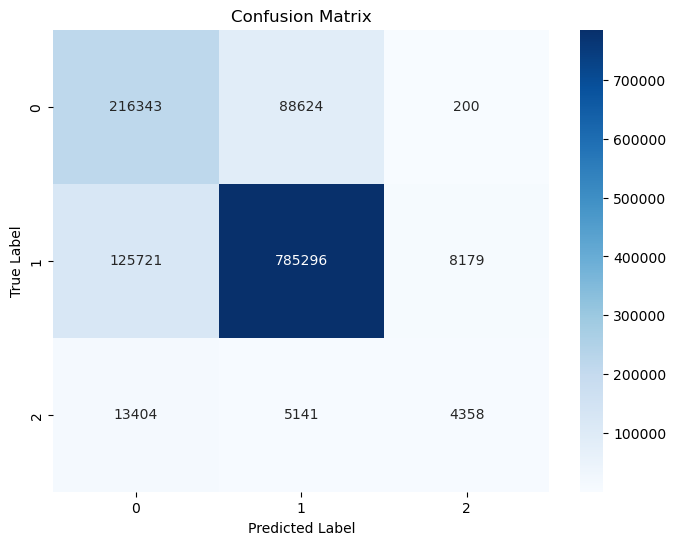

[[216343  88624    200]
 [125721 785296   8179]
 [ 13404   5141   4358]]


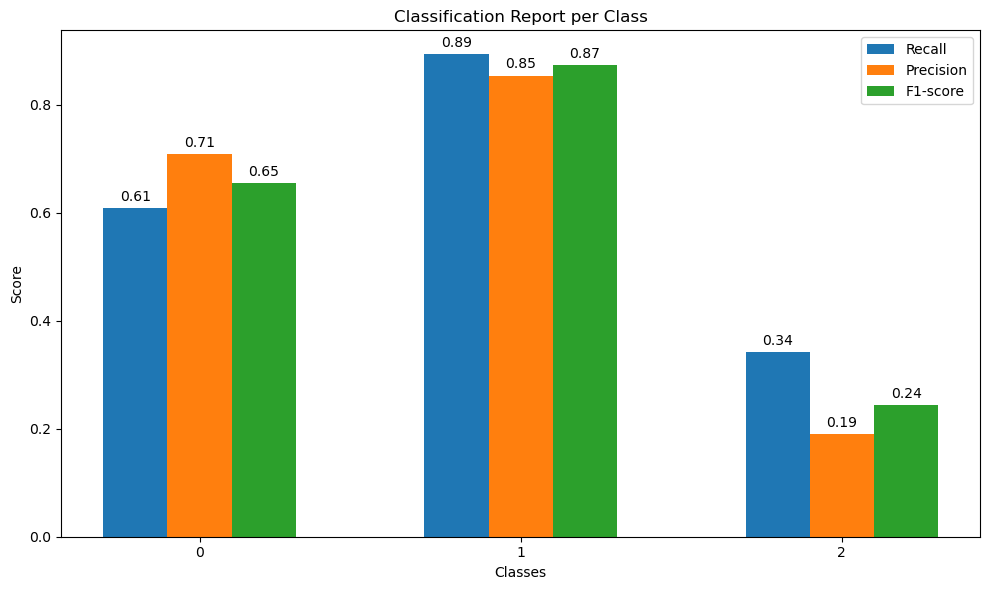

In [9]:
#{'n_estimators': 441, 'learning_rate': 0.0895186049880042, 'num_leaves': 98, 'max_depth': 8, 'min_child_samples': 34, 'subsample': 0.7024962299198043, 'colsample_bytree': 0.8199213047640314}
#{'n_estimators': 345, 'learning_rate': 0.14684938411644088, 'num_leaves': 84, 'max_depth': 2, 'min_child_samples': 35, 'subsample': 0.7612682679076272, 'colsample_bytree': 0.794302592358768}

lgbm = lgb.LGBMClassifier(verbose=-1, n_estimators=345, learning_rate=0.14684938411644088, num_leaves=84, max_depth=2, 
                          min_child_samples=35, subsample=0.7612682679076272, colsample_bytree=0.794302592358768, random_state=42, is_unbalance=True)
evaluate(lgbm)

In [9]:
importances = lgbm.feature_importances_
feature_importances = pd.DataFrame({'Feature': x_cols, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False).reset_index(drop=True)

top_features = feature_importances.head(30)
top_feature_names = top_features['Feature'].tolist()
top_feature_names

['total_seconds',
 'AvgPacketLen_Mean',
 'Avg source IP count',
 'Max_DetectCount',
 'Std_DataSpeed',
 'AvgPacketLen_Std',
 'Min_PacketSpeed',
 'Sin_DayOfYear',
 'Cos_DayOfYear',
 'Mean_DataSpeed',
 'Max_DataSpeed',
 'Mean_PacketSpeed',
 'Attack ID',
 'Max_PacketSpeed',
 'Victim IP',
 'AvgPacketLen_Per_TotalSeconds',
 'Mean_DetectCount',
 'Start Hour',
 'Min_DataSpeed',
 'DayOfYear',
 'VictimIP_Count',
 'Std_DetectCount',
 'PCA_3',
 'PCA_4',
 'PacketSpeed_Per_Second',
 'Source IP count',
 'PCA_2',
 'umap_2',
 'Is_SSH',
 'dist_centroid_silhouette_54']

In [27]:
#w smote
"""Accuracy: 0.8111389230525005
Precision: 0.670946848156344
Recall: 0.5834843327517265
F1-Score: 0.6068882307103756"""
#wo smote
"""Accuracy: 0.7763556450668903
Precision: 0.6314237782732396
Recall: 0.5448904317256309
F1-Score: 0.5687628012192705"""

'Accuracy: 0.7763556450668903\nPrecision: 0.6314237782732396\nRecall: 0.5448904317256309\nF1-Score: 0.5687628012192705'

# CatBoost


Learning rate set to 0.116035
0:	learn: 0.9408720	total: 368ms	remaining: 6m 7s
1:	learn: 0.8234261	total: 629ms	remaining: 5m 13s
2:	learn: 0.7360948	total: 856ms	remaining: 4m 44s
3:	learn: 0.6619715	total: 1.1s	remaining: 4m 33s
4:	learn: 0.6060807	total: 1.33s	remaining: 4m 23s
5:	learn: 0.5582362	total: 1.54s	remaining: 4m 16s
6:	learn: 0.5169393	total: 1.79s	remaining: 4m 13s
7:	learn: 0.4813339	total: 2.05s	remaining: 4m 14s
8:	learn: 0.4537821	total: 2.26s	remaining: 4m 8s
9:	learn: 0.4255476	total: 2.52s	remaining: 4m 9s
10:	learn: 0.4018120	total: 2.77s	remaining: 4m 8s
11:	learn: 0.3809664	total: 3.03s	remaining: 4m 9s
12:	learn: 0.3622811	total: 3.27s	remaining: 4m 8s
13:	learn: 0.3460003	total: 3.54s	remaining: 4m 9s
14:	learn: 0.3320028	total: 3.79s	remaining: 4m 8s
15:	learn: 0.3191874	total: 4.08s	remaining: 4m 11s
16:	learn: 0.3064520	total: 4.33s	remaining: 4m 10s
17:	learn: 0.2957795	total: 4.58s	remaining: 4m 9s
18:	learn: 0.2865679	total: 4.84s	remaining: 4m 9s
19:

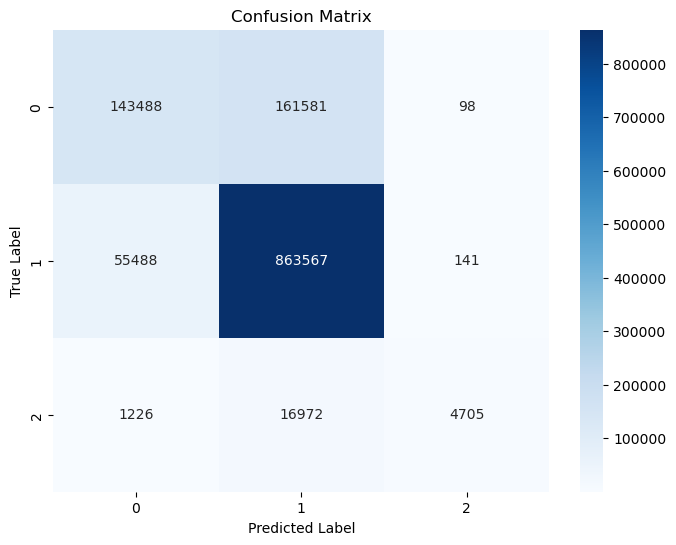

[[143488 161581     98]
 [ 55488 863567    141]
 [  1226  16972   4705]]


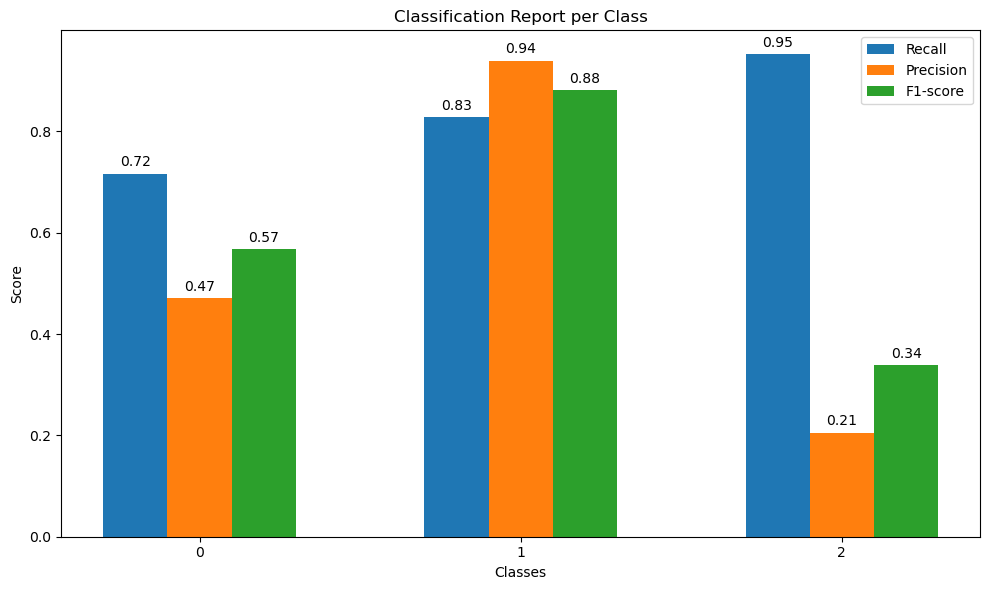

In [28]:
# check catboost version
import catboost as cat
cgbm = cat.CatBoostClassifier(verbose=1, random_seed=42, loss_function='MultiClass')

evaluate(cgbm)

In [29]:
#w smote
"""Accuracy: 0.7763556450668903
Precision: 0.6314237782732396
Recall: 0.5448904317256309
F1-Score: 0.5687628012192705"""
#w smote
"""Accuracy: 0.7992240628703099
Precision: 0.6110429618065945
Recall: 0.5628038211345253
F1-Score: 0.5825504082708981"""

'Accuracy: 0.7992240628703099\nPrecision: 0.6110429618065945\nRecall: 0.5628038211345253\nF1-Score: 0.5825504082708981'

# Verdict


In [30]:
# RFC
    # After SMOTE *2
    """Accuracy: 0.8212698814847835
    Precision: 0.6796352669253373
    Recall: 0.5641607988228415
    F1-Score: 0.5968541729821948"""
    
    # After SMOTE *1.5
    """Accuracy: 0.8317616290350254
    Precision: 0.8383765643300584
    Recall: 0.5832465366868779
    F1-Score: 0.6230823834637998"""
    
    # After SMOTE *1.2
    # After SMOTE *1.7

# GBC
    # After SMOTE *2
    """Accuracy: 0.7427100554332436
    Precision: 0.5302445031077706
    Recall: 0.6432907285227544
    F1-Score: 0.5557385293452168"""
    
    # After SMOTE *1.5
    """Accuracy: 0.7537750568042423
    Precision: 0.5499038794403751
    Recall: 0.6752129126613243
    F1-Score: 0.5814952853168204"""

IndentationError: unexpected indent (4131684684.py, line 3)

In [ ]:
# CNN
    #simple simply
    """Test Loss:     11098.7607
    Test Accuracy: 0.7891"""
    #simple smote
    """Test Loss:     10123.3623
    Test Accuracy: 0.7939"""
    
    #complex simply
    """Test Loss:     0.6736
    Test Accuracy: 0.7370"""
    #complex smote
    """Test Loss:     0.6572
    Test Accuracy: 0.7370"""